In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import norm
import pandas as pd
from scipy import stats
from itertools import product
from scipy import linalg
from functools import partial

# Add the parent directory (simcode) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dgp import GaussianNetwork, BernoulliNetwork

from src.helper_functions.plot_functions import visualise_latent

In [ ]:
rng = np.random.default_rng(42)
copula_types = ['gaussian', 'gaussian', 'gaussian', 'frank', 'rotated_clayton', 'mixture_uniform']

params = {
    'copula_type' : ['gaussian', 'gaussian', 'gaussian', 
                     'clayton', 'gumbel', #'gaussian', 
                     'frank', 'student_t', 'mixture_uniform',
                     'mixture_uniform', 'mixture_uniform', #'mixture_uniform'
                     ],
    
    'marginals' : ['gaussian', 'gaussian', 'uniform -1 1', 
                   'gaussian', 'gaussian', #{'x': 'gaussian', 'z': 'lognormal 0.75'},
                   'gaussian', 'gaussian', 'gaussian',
                   'uniform -1 1', 't 5', #'chi2 5'
                   ],
    'weights' : [[], [], [], 
                 [], [],
                 [], [], [0.5, 0.5],
                 [0.5, 0.5],[0.5, 0.5],
                 ],
    
    'correlations' : [[], [], [], 
                      [], [], #[],
                      [], [], [0.98, -0.98],
                      [0.98, -0.98],[0.98, -0.98],#[0.98, -0.98],
                      ],
    
    'titles': ['Gaussian Independent', 'Gaussian Correlated', 'Uniform marginals',
               'Clayton', 'Gumbel', #'Exponential',
               'Frank', 'Student t', 'Star mixture gaussian',
               'Star mixture uniform', 'Star mixture t', #'Star mixture chi2',

               ],
    'rho': [0, 0.75, 0.75, 0.75,  0.75, 0.75, 0.75, 0.75, 0.75, 0.75]
}


X_list, Z_list = [], []

for (copula_type, marginals, weights, correlations, rho) in zip(params['copula_type'], params['marginals'], params['weights'], params['correlations'], params['rho']):
    m = GaussianNetwork(n=1000, k=3, rho=rho, rng=rng, 
                        copula_model=copula_type, marginals=marginals,
                        weights=weights, correlations=correlations
                        )
    data = m.generate()
    X_list.append(data['X'])
    Z_list.append(data['Z'])

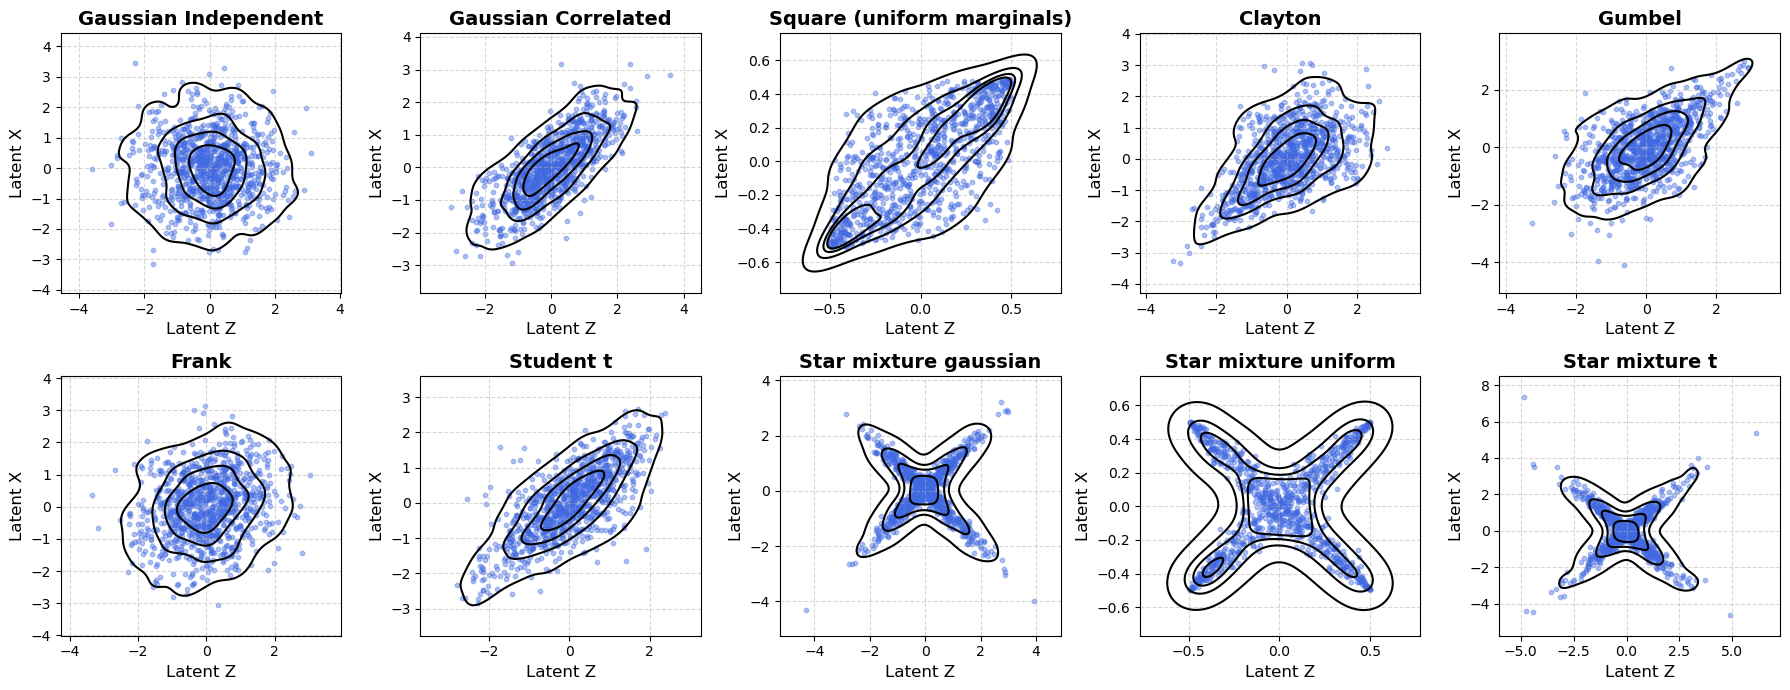

In [34]:
visualise_latent(Z_list, X_list, titles=params['titles'], 
                 shape=(2, 5), figsize=(18, 7), k=1, 
                 kdplot=True, sharex=False, sharey=False)

In [35]:
visualise_latent(Z_list, X_list, titles=params['titles'], 
                 shape=(2, 5), figsize=(18, 7), k=1, 
                 kdplot=True, sharex=False, sharey=False, save_path='visualise_latent')